In [1]:
%load_ext autoreload
%autoreload 2

from cdk.analysis.cytosol import platereader as pr
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
# import hvplot.pandas
import cdk.logging
import logging

log = cdk.logging.setup_logging(log_level=logging.DEBUG)
pr.plot_setup()

[07/15/25 00:32:50] INFO     Logging initialized                  __init__.py:44


In [3]:
pr.plot_setup()

Load data

In [4]:
data, platemap = pr.load_platereader_data("../../tests/test_data/cytation_dna_sweep.txt", "../../tests/test_data/platemap.csv")
data.head()


                    DEBUG    Reading Cytation data from       platereader.py:339
                             ../../tests/test_data/cytation_d                   
                             na_sweep.txt                                       


,Well,Row,Column,Time,Seconds,Temperature (C),Read,Data,Experiment,Name,DNA Template,[DNA Template] (ng/uL)
0,B1,B,1,0 days 00:00:00,0.00,37.0,"490,520",289.00,Concentration,pT7-deGFP 100,pT7-deGFP (AR-11),100.00
1,B1,B,1,0 days 00:05:00,300.00,37.1,"490,520",312.00,Concentration,pT7-deGFP 100,pT7-deGFP (AR-11),100.00
2,B1,B,1,0 days 00:10:00,600.00,37.0,"490,520",449.00,Concentration,pT7-deGFP 100,pT7-deGFP (AR-11),100.00
3,B1,B,1,0 days 00:15:00,900.00,37.0,"490,520",982.00,Concentration,pT7-deGFP 100,pT7-deGFP (AR-11),100.00
4,B1,B,1,0 days 00:20:00,1200.00,37.0,"490,520",1880.00,Concentration,pT7-deGFP 100,pT7-deGFP (AR-11),100.00


In [31]:
data = pd.read_csv("../../tests/test_data/platereader-test-data.csv")
data["Time"] = pd.to_timedelta(data["Time"])
data.head()

,Time,Well,Row,Column,Read,Experiment,Type,Name,DNA,[DNA] (ng/uL),Data
0,0 days 00:00:00,A1,A,1,GFP,Experiment,Blank,Blank,NaN,0,0.00
1,0 days 00:05:00,A1,A,1,GFP,Experiment,Blank,Blank,NaN,0,0.00
2,0 days 00:10:00,A1,A,1,GFP,Experiment,Blank,Blank,NaN,0,0.00
3,0 days 00:15:00,A1,A,1,GFP,Experiment,Blank,Blank,NaN,0,0.00
4,0 days 00:20:00,A1,A,1,GFP,Experiment,Blank,Blank,NaN,0,0.00


In [32]:
data["Name"].unique()

array(['Blank', 'S1', 'S2', 'S3'], dtype=object)

In [33]:
data = pr.blank_data(data)

# Basic Plots

Look at a plot of plate reader data, laid out the same as the plate.

[11/04/24 18:04:18] DEBUG    Loaded backend                        pyplot.py:487
                             module://matplotlib_inline.backend_in              
                             line version unknown.                              
                    DEBUG    Loaded backend                        pyplot.py:487
                             module://matplotlib_inline.backend_in              
                             line version unknown.                              
                    DEBUG    findfont: Matching             font_manager.py:1416
                             sans\-serif:style=normal:varia                     
                             nt=normal:weight=normal:stretc                     
                             h=normal:size=10.0.                                
                    DEBUG    findfont:                      font_manager.py:1428
                             score(FontEntry(fname='/Users/                     
                            

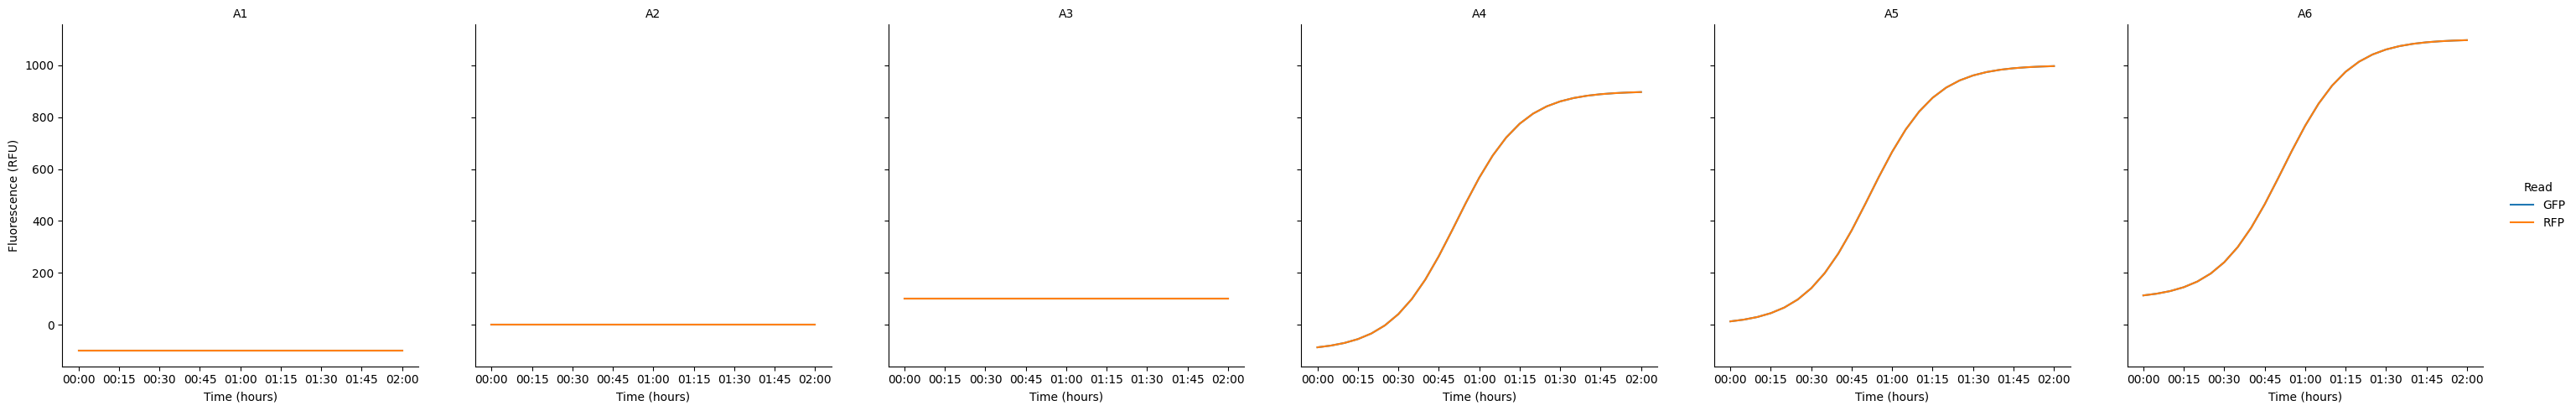

In [3]:
pr.plot_plate(data)

## Time-series Traces

Plot all curves, with one plot per experiment.

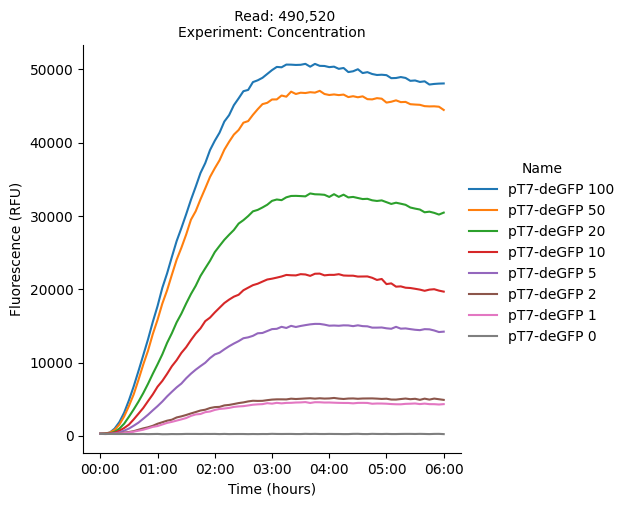

In [4]:
import cdk.analysis.cytosol.platereader as pr

data = pr.load_platereader_data("../../tests/test_data/cytation_dna_sweep.txt", "../../tests/test_data/platemap.csv")[0]
pr.plot_curves_by_name(data[data["Experiment"] == "Concentration"])

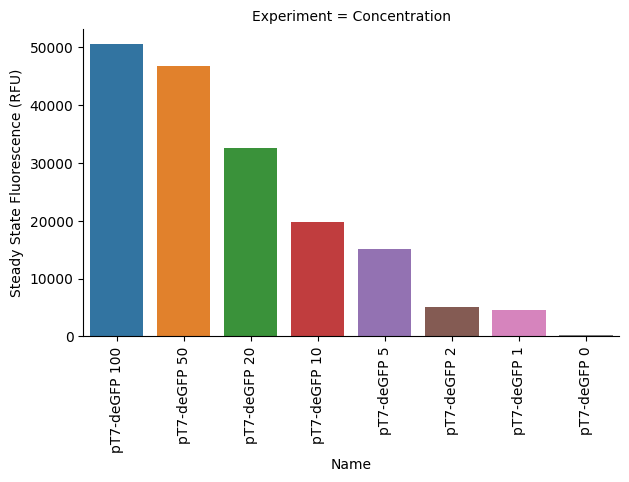

In [8]:
pr.plot_steadystate(data[data["Experiment"] == "Concentration"], hue="Name", native_scale=False)

[11/04/24 18:05:00] DEBUG    var_len=10                       platereader.py:426


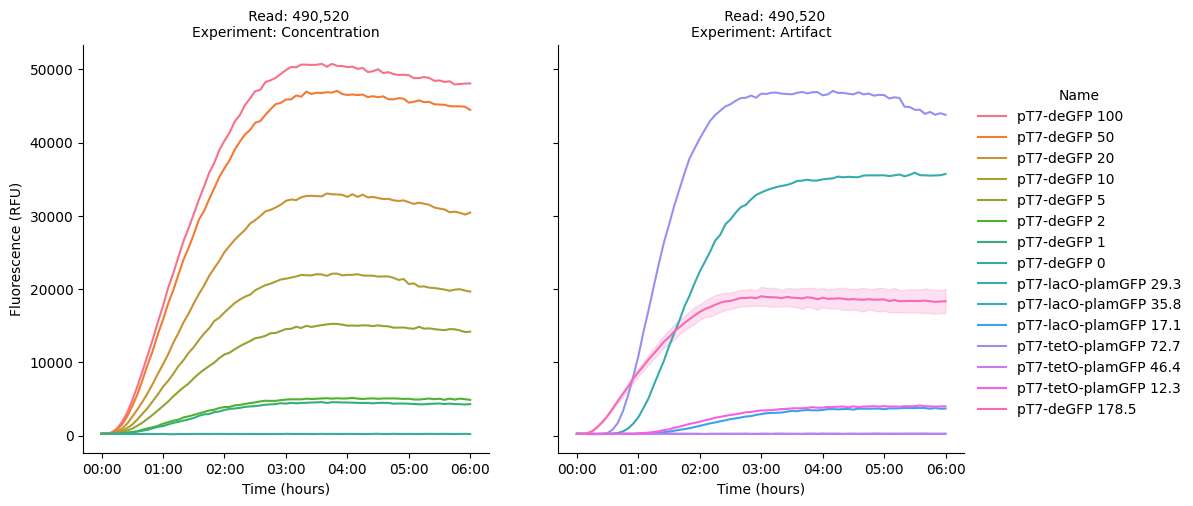

In [5]:
pr.plot_curves_by_name(data=data)

Plot curves with control over how the data is separated.

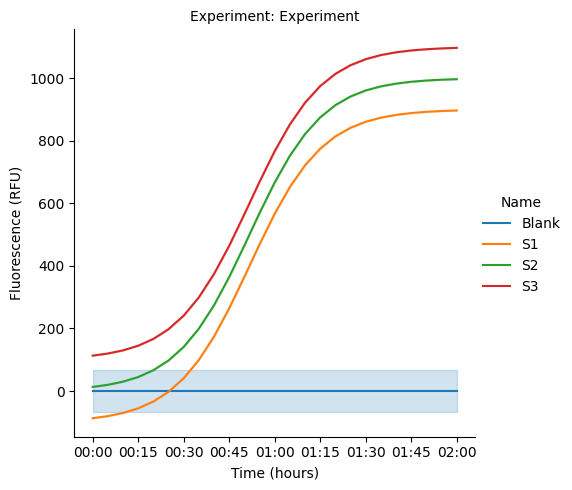

In [44]:
pr.plot_curves(data, hue="Name", col="Experiment")

In [96]:
platemap

,Well,Experiment,Name,DNA Template,[DNA Template] (ng/uL)
0,B1,Concentration,pT7-deGFP 100,pT7-deGFP (AR-11),100.00
1,B2,Concentration,pT7-deGFP 50,pT7-deGFP (AR-11),50.00
2,B3,Concentration,pT7-deGFP 20,pT7-deGFP (AR-11),20.00
3,B4,Concentration,pT7-deGFP 10,pT7-deGFP (AR-11),10.00
4,B5,Concentration,pT7-deGFP 5,pT7-deGFP (AR-11),5.00
5,B6,Concentration,pT7-deGFP 2,pT7-deGFP (AR-11),2.00
6,B7,Concentration,pT7-deGFP 1,pT7-deGFP (AR-11),1.00
7,B8,Concentration,pT7-deGFP 0,pT7-deGFP (AR-11),0.00
8,C1,Artifact,pT7-lacO-plamGFP 29.3,pT7-lacO-plamGFP (20240622),29.30
9,C2,Artifact,pT7-lacO-plamGFP 35.8,pT7-lacO-plamGFP (20240626),35.80


## Steady State

Plot steady state fluorescence based on our steady state definition. There are three potential ways to calculate steady state:
1. Steady state determined by the point of minimum change (i.e., where velocity is closest to zero). This is what we do by default.
2. Steady state determined by the maximum fluorescence value. This is the simplest to explain and understand.
3. Steady state as calculated by the intercept of the $V_{max}$ line with the maximum data value. This tends to match our intuition about where the steady state is the least, but has pleasing symmetry with the way we calculate the lag time (intercept of $V_{max}$ with zero).
    

In [46]:
data.head()

,Time,Well,Row,Column,Read,Experiment,Type,Name,DNA,[DNA] (ng/uL),Data,Data_blank,Data_unblanked
0,0 days 00:00:00,A1,A,1,GFP,Experiment,Blank,Blank,NaN,0,-100.00,100.00,0.00
1,0 days 00:05:00,A1,A,1,GFP,Experiment,Blank,Blank,NaN,0,-100.00,100.00,0.00
2,0 days 00:10:00,A1,A,1,GFP,Experiment,Blank,Blank,NaN,0,-100.00,100.00,0.00
3,0 days 00:15:00,A1,A,1,GFP,Experiment,Blank,Blank,NaN,0,-100.00,100.00,0.00
4,0 days 00:20:00,A1,A,1,GFP,Experiment,Blank,Blank,NaN,0,-100.00,100.00,0.00


In [ ]:
pr.find_steady_state(data)

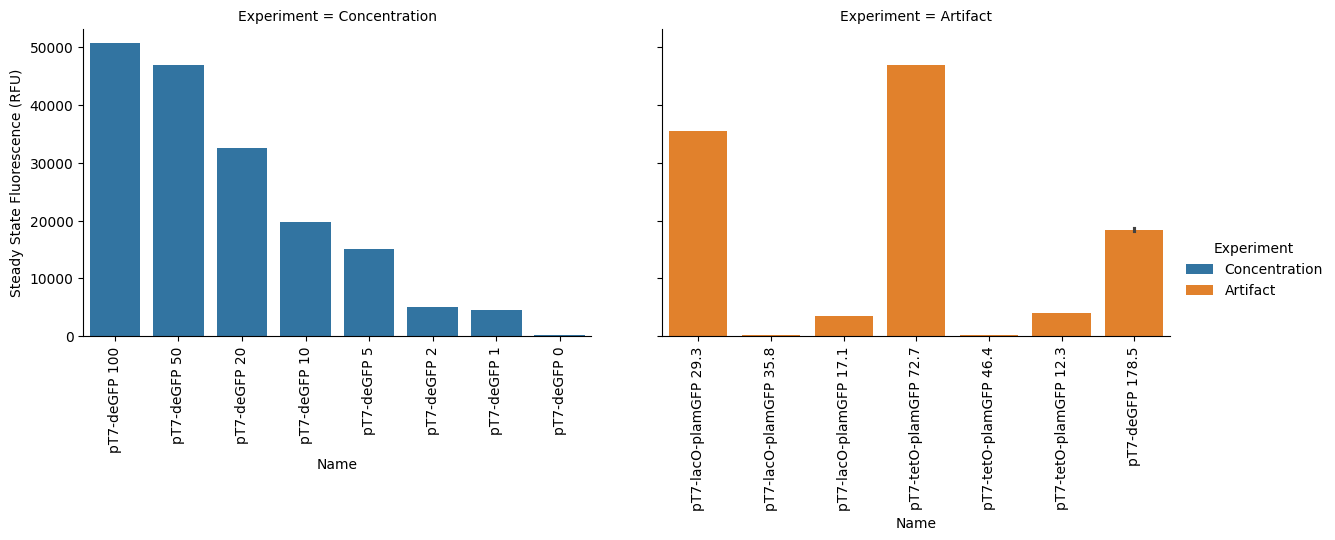

In [65]:
pr.plot_steadystate(data)

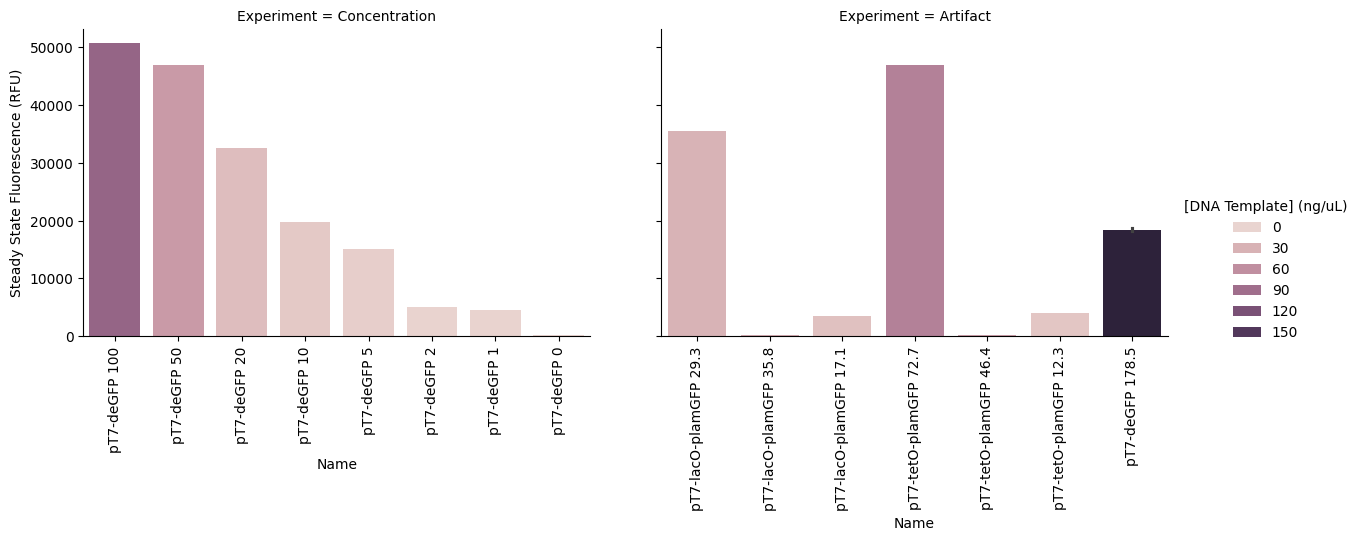

In [75]:
pr.plot_steadystate(data, hue="[DNA Template] (ng/uL)")

*add scatter?*

# Kinetics

Determine Kinetic Parameters

If kinetics can't be solved for a given well, a warning will be printed and that well will have "Not a Number" (NaN) or "Not a Time" (NaT) for the relevant parameters.

In [4]:
kinetics = pr.kinetic_analysis(data)
kinetics

[11/04/24 23:15:07] WARNING  Failed to solve: Optimal         platereader.py:505
                             parameters not found: Number of                    
                             calls to function has reached                      
                             maxfev = 800.                                      
                    WARNING  Failed to solve: Optimal         platereader.py:505
                             parameters not found: Number of                    
                             calls to function has reached                      
                             maxfev = 800.                                      


Velocity                                      Lag          \
                        Time     Data   Max                      Time    Data   
Well Read                                                                       
B1   490,520 0 days 01:05:00 20189.00  8.28 0 days 00:24:22.696177062 5339.74   
B2   490,520 0 days 00:55:00 13878.00  7.56 0 days 00:24:23.475959418 4818.95   
B3   490,520 0 days 01:10:00 12679.00  5.22 0 days 00:29:31.072796935 3579.02   
B4   490,520 0 days 01:00:00  6700.00  3.50 0 days 00:28:05.714285714 2071.91   
B5   490,520 0 days 01:30:00  7850.00  2.40 0 days 00:35:33.703190014 1864.95   
B6   490,520 0 days 01:20:00  2502.00  1.02 0 days 00:38:59.016393443  872.68   
B7   490,520 0 days 01:35:00  2718.00  0.98 0 days 00:48:46.530612245    0.00   
B8   490,520 0 days 03:00:00   268.00  0.09 0 days 02:12:08.571428571    0.00   
C1   490,520 0 days 01:30:00 12223.00  6.60 0 days 00:59:08.965169107 3770.87   
C2   490,520             NaT      NaN   NaN                       NaT     NaN   
C3   490,520 0 days 02:05:00  1524.00  0.57 0 days 01:20:41.860465116  523.35   
C4   490,520 0 days 01:05:00 14167.00 11.06 0 days 00:43:38.691588785 4762.91   
C5   490,520             NaT      NaN   NaN                       NaT     NaN   
C6   490,520 0 days 01:35:00  1093.00  0.74 0 days 01:10:22.972972973  562.43   
C7   490,520 0 days 00:55:00  8308.00  3.84 0 days 00:18:54.578627281 2148.57   
C8   490,520 0 days 00:55:00  7234.00  3.37 0 days 00:19:11.287128713 1848.80   

                Steady State               Fit               
                        Time     Data        L    k      x0  
Well Read                                                    
B1   490,520 0 days 03:30:00 50621.00 50290.12 0.00 4778.93  
B2   490,520 0 days 03:45:00 46821.00 46486.67 0.00 4884.37  
B3   490,520 0 days 04:25:00 32592.00 32753.46 0.00 5162.19  
B4   490,520 0 days 05:55:00 19808.00 21291.85 0.00 4989.96  
B5   490,520 0 days 04:30:00 15073.00 15073.09 0.00 5411.88  
B6   490,520 0 days 04:10:00  5075.00  5093.57 0.00 5063.40  
B7   490,520 0 days 03:20:00  4498.00     0.00 0.00    0.00  
B8   490,520 0 days 03:20:00   253.00     0.00 0.00    0.00  
C1   490,520 0 days 05:10:00 35535.00 35013.27 0.00 6447.70  
C2   490,520             NaT      NaN      NaN  NaN     NaN  
C3   490,520 0 days 03:55:00  3464.00  3673.27 0.00 8207.27  
C4   490,520 0 days 03:55:00 46897.00 46427.49 0.00 4904.73  
C5   490,520             NaT      NaN      NaN  NaN     NaN  
C6   490,520 0 days 04:45:00  4008.00  3949.34 0.00 7376.26  
C7   490,520 0 days 04:25:00 20034.00 20073.07 0.00 4012.84  
C8   490,520 0 days 05:30:00 16839.00 17333.19 0.00 3952.78

Plot Kinetics

[11/04/24 23:15:10] INFO     Kinetics information not         platereader.py:622
                             available for C2.                                  
                    INFO     Kinetics information not         platereader.py:622
                             available for C5.                                  


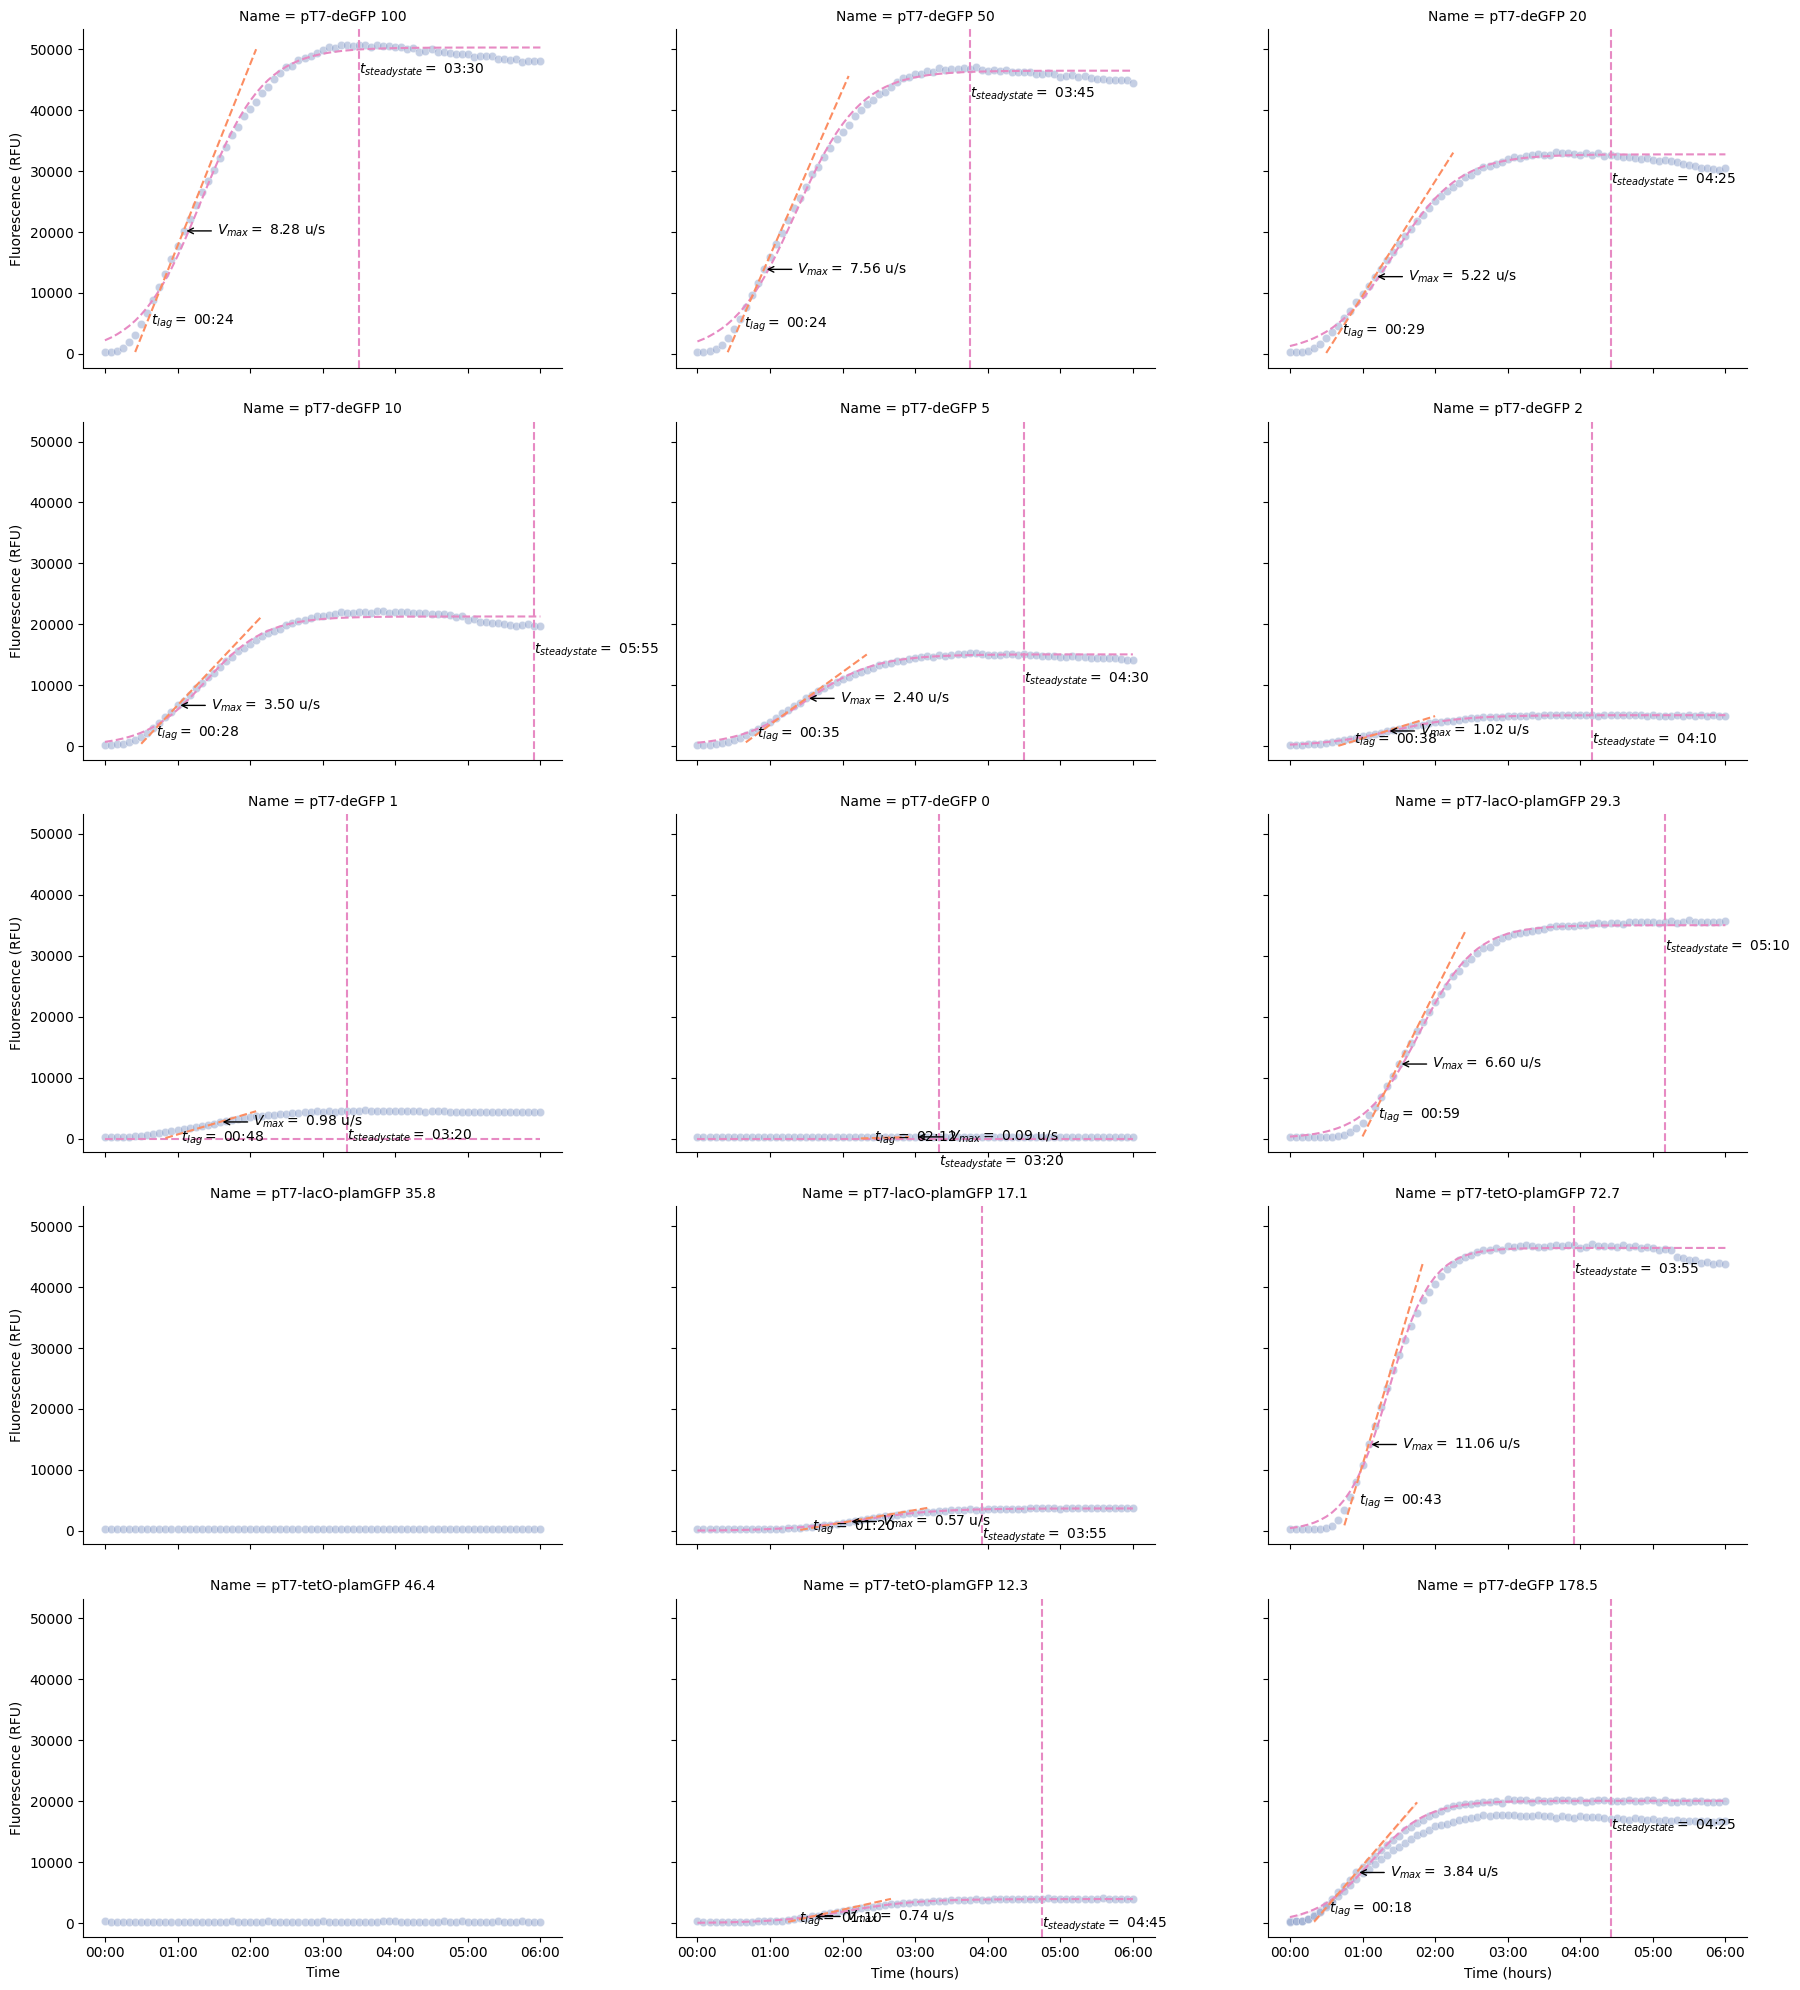

In [5]:
pr.plot_kinetics(data, kinetics, col_wrap=4)

# HVplot

In [11]:
data.hvplot(
    by=['[DNA Template] (ng/uL)'],
    groupby=['Experiment'],
    kind='line',
    logy=False,
    x='Time',
    y=['Data'],
    legend='bottom_right',
    widget_location='top',
    height=500,
    width=1000
)

BokehModel(combine_events=True, render_bundle={'docs_json': {'d1b4562c-207c-486f-9fad-87dffaaa2504': {'version…

In [7]:
data.hvplot.explorer(x="Time", y="Data", by=["Name"], groupby=["Experiment"])

BokehModel(combine_events=True, render_bundle={'docs_json': {'29b4b1a6-625b-4805-879a-63b27d958eef': {'version…

UnknownReferenceError: can't resolve reference 'p3936'

UnknownReferenceError: can't resolve reference 'p3936'

UnknownReferenceError: can't resolve reference 'p4243'

UnknownReferenceError: can't resolve reference 'p4243'

UnknownReferenceError: can't resolve reference 'p4243'

UnknownReferenceError: can't resolve reference 'p4243'

# Multiplate

In [123]:
data = pr.read_biotek_cdk("../../tests/test_data/biotek_cdk_multiplate.txt")
data

[07/11/25 13:19:13] DEBUG    Reading CDK-formatted BioTek     platereader.py:235
                             data from                                          
                             ../../tests/test_data/biotek_cdk                   
                             _multiplate.txt                                    
                    DEBUG    Found metadata: CDK -> cdk       platereader.py:246
                    DEBUG    Found metadata: Procedure        platereader.py:246
                             Summary -> procedure_summary                       
                    DEBUG    Loaded section PURE:GFP-F-G35    platereader.py:263
                    DEBUG    Data loaded with columns:        platereader.py:309
                             Index(['Time', 'Well', 'Data'],                    
                             dtype='object')                                    
                    DEBUG    Found metadata: CDK -> cdk       platereader.py:246
                    DEBUG   

,Time,Well,Data,Row,Column,Read,Plate,Clock Time
0,0 days 00:00:00,B2,27.00,B,2,GFP-F-G35,Plate 1,2025-07-08 16:28:05
1,0 days 00:05:00,B2,26.00,B,2,GFP-F-G35,Plate 1,2025-07-08 16:33:05
2,0 days 00:10:00,B2,25.00,B,2,GFP-F-G35,Plate 1,2025-07-08 16:38:05
3,0 days 00:15:00,B2,26.00,B,2,GFP-F-G35,Plate 1,2025-07-08 16:43:05
4,0 days 00:20:00,B2,26.00,B,2,GFP-F-G35,Plate 1,2025-07-08 16:48:05
...,...,...,...,...,...,...,...,...
5616,0 days 05:40:00,H12,12.00,H,12,GFP-F-G35,Plate 2,2025-07-08 22:41:12
5617,0 days 05:45:00,H12,12.00,H,12,GFP-F-G35,Plate 2,2025-07-08 22:46:12
5618,0 days 05:50:00,H12,12.00,H,12,GFP-F-G35,Plate 2,2025-07-08 22:51:12
5619,0 days 05:55:00,H12,12.00,H,12,GFP-F-G35,Plate 2,2025-07-08 22:56:12


In [2]:
data, platemap = pr.load_platereader_data("../../tests/test_data/biotek_cdk_multiplate.txt", "../../tests/test_data/biotek_cdk_multiplate_platemap.tsv", platereader="biotek-cdk")
data.head()

[07/15/25 00:32:59] DEBUG    Reading CDK-formatted BioTek     platereader.py:233
                             data from                                          
                             ../../tests/test_data/biotek_cdk                   
                             _multiplate.txt                                    
                    DEBUG    Found metadata: CDK -> cdk       platereader.py:244
                    DEBUG    Found metadata: Procedure        platereader.py:244
                             Summary -> procedure_summary                       
                    DEBUG    Loaded section PURE:GFP-F-G35    platereader.py:269
                    DEBUG    Data loaded with columns:        platereader.py:315
                             Index(['Time', 'Well', 'Data'],                    
                             dtype='object')                                    
                    DEBUG    Found metadata: CDK -> cdk       platereader.py:244
                    DEBUG   

                    DEBUG    Data loaded with columns:        platereader.py:315
                             Index(['Time', 'Well', 'Data'],                    
                             dtype='object')                                    


,Time,Well,Data,Row,Column,Read,Plate,Clock Time,Type,Name,Replicate,Emix,Pmix,[Pmix] (mg/mL),Energy Mix (uL),Protein Mix (uL),Ribosomes (uL),RNAse I (uL),DNA (uL),ddH2O (uL)
0,0 days 00:00:00,B2,27.00,B,2,GFP-F-G35,Plate 1,2025-07-08 16:28:05,Sample,I -,1,NEB SolA,I -,NaN,4,1.20,1.80,0.50,1.00,1.50
1,0 days 00:05:00,B2,26.00,B,2,GFP-F-G35,Plate 1,2025-07-08 16:33:05,Sample,I -,1,NEB SolA,I -,NaN,4,1.20,1.80,0.50,1.00,1.50
2,0 days 00:10:00,B2,25.00,B,2,GFP-F-G35,Plate 1,2025-07-08 16:38:05,Sample,I -,1,NEB SolA,I -,NaN,4,1.20,1.80,0.50,1.00,1.50
3,0 days 00:15:00,B2,26.00,B,2,GFP-F-G35,Plate 1,2025-07-08 16:43:05,Sample,I -,1,NEB SolA,I -,NaN,4,1.20,1.80,0.50,1.00,1.50
4,0 days 00:20:00,B2,26.00,B,2,GFP-F-G35,Plate 1,2025-07-08 16:48:05,Sample,I -,1,NEB SolA,I -,NaN,4,1.20,1.80,0.50,1.00,1.50


In [155]:
plates = ["Plate 1", "Plate 2"]
dfs = [data[data["Plate"] == plates[0]]]

for prev_plate, plate in zip(plates[:-1], plates[1:]):
    p = data[data["Plate"] == plate].copy()
    p["Time"] = p["Clock Time"] - data[data["Plate"] == prev_plate].iloc[0]["Clock Time"]
    dfs.append(p)
    
data_merge = pd.concat(dfs).drop("Plate", axis=1)

In [156]:
print(dfs[0].shape)
print(dfs[1].shape)

(108, 20)
(1314, 20)


In [25]:
data_merge = pr.merge_plates(data)
data_merge[data_merge["Well"] == "B2"].head(20)

[07/14/25 15:03:20] DEBUG    Start time: 2025-07-08 16:28:05 platereader.py:1233


,Time,Well,Data,Row,Column,Read,Plate,Clock Time,Type,Name,Replicate,Emix,Pmix,[Pmix] (mg/mL),Energy Mix (uL),Protein Mix (uL),Ribosomes (uL),RNAse I (uL),DNA (uL),ddH2O (uL)
0,0 days 00:00:00,B2,27.00,B,2,GFP-F-G35,Plate 1,2025-07-08 16:28:05,Sample,I -,1,NEB SolA,I -,NaN,4,1.20,1.80,0.50,1.00,1.50
1,0 days 00:05:00,B2,26.00,B,2,GFP-F-G35,Plate 1,2025-07-08 16:33:05,Sample,I -,1,NEB SolA,I -,NaN,4,1.20,1.80,0.50,1.00,1.50
2,0 days 00:10:00,B2,25.00,B,2,GFP-F-G35,Plate 1,2025-07-08 16:38:05,Sample,I -,1,NEB SolA,I -,NaN,4,1.20,1.80,0.50,1.00,1.50
3,0 days 00:15:00,B2,26.00,B,2,GFP-F-G35,Plate 1,2025-07-08 16:43:05,Sample,I -,1,NEB SolA,I -,NaN,4,1.20,1.80,0.50,1.00,1.50
4,0 days 00:20:00,B2,26.00,B,2,GFP-F-G35,Plate 1,2025-07-08 16:48:05,Sample,I -,1,NEB SolA,I -,NaN,4,1.20,1.80,0.50,1.00,1.50
5,0 days 00:25:00,B2,28.00,B,2,GFP-F-G35,Plate 1,2025-07-08 16:53:05,Sample,I -,1,NEB SolA,I -,NaN,4,1.20,1.80,0.50,1.00,1.50
108,0 days 00:33:07,B2,32.00,B,2,GFP-F-G35,Plate 1,2025-07-08 17:01:12,Sample,I -,1,NEB SolA,I -,NaN,4,1.20,1.80,0.50,1.00,1.50
109,0 days 00:38:07,B2,42.00,B,2,GFP-F-G35,Plate 1,2025-07-08 17:06:12,Sample,I -,1,NEB SolA,I -,NaN,4,1.20,1.80,0.50,1.00,1.50
110,0 days 00:43:07,B2,54.00,B,2,GFP-F-G35,Plate 1,2025-07-08 17:11:12,Sample,I -,1,NEB SolA,I -,NaN,4,1.20,1.80,0.50,1.00,1.50
111,0 days 00:48:07,B2,71.00,B,2,GFP-F-G35,Plate 1,2025-07-08 17:16:12,Sample,I -,1,NEB SolA,I -,NaN,4,1.20,1.80,0.50,1.00,1.50


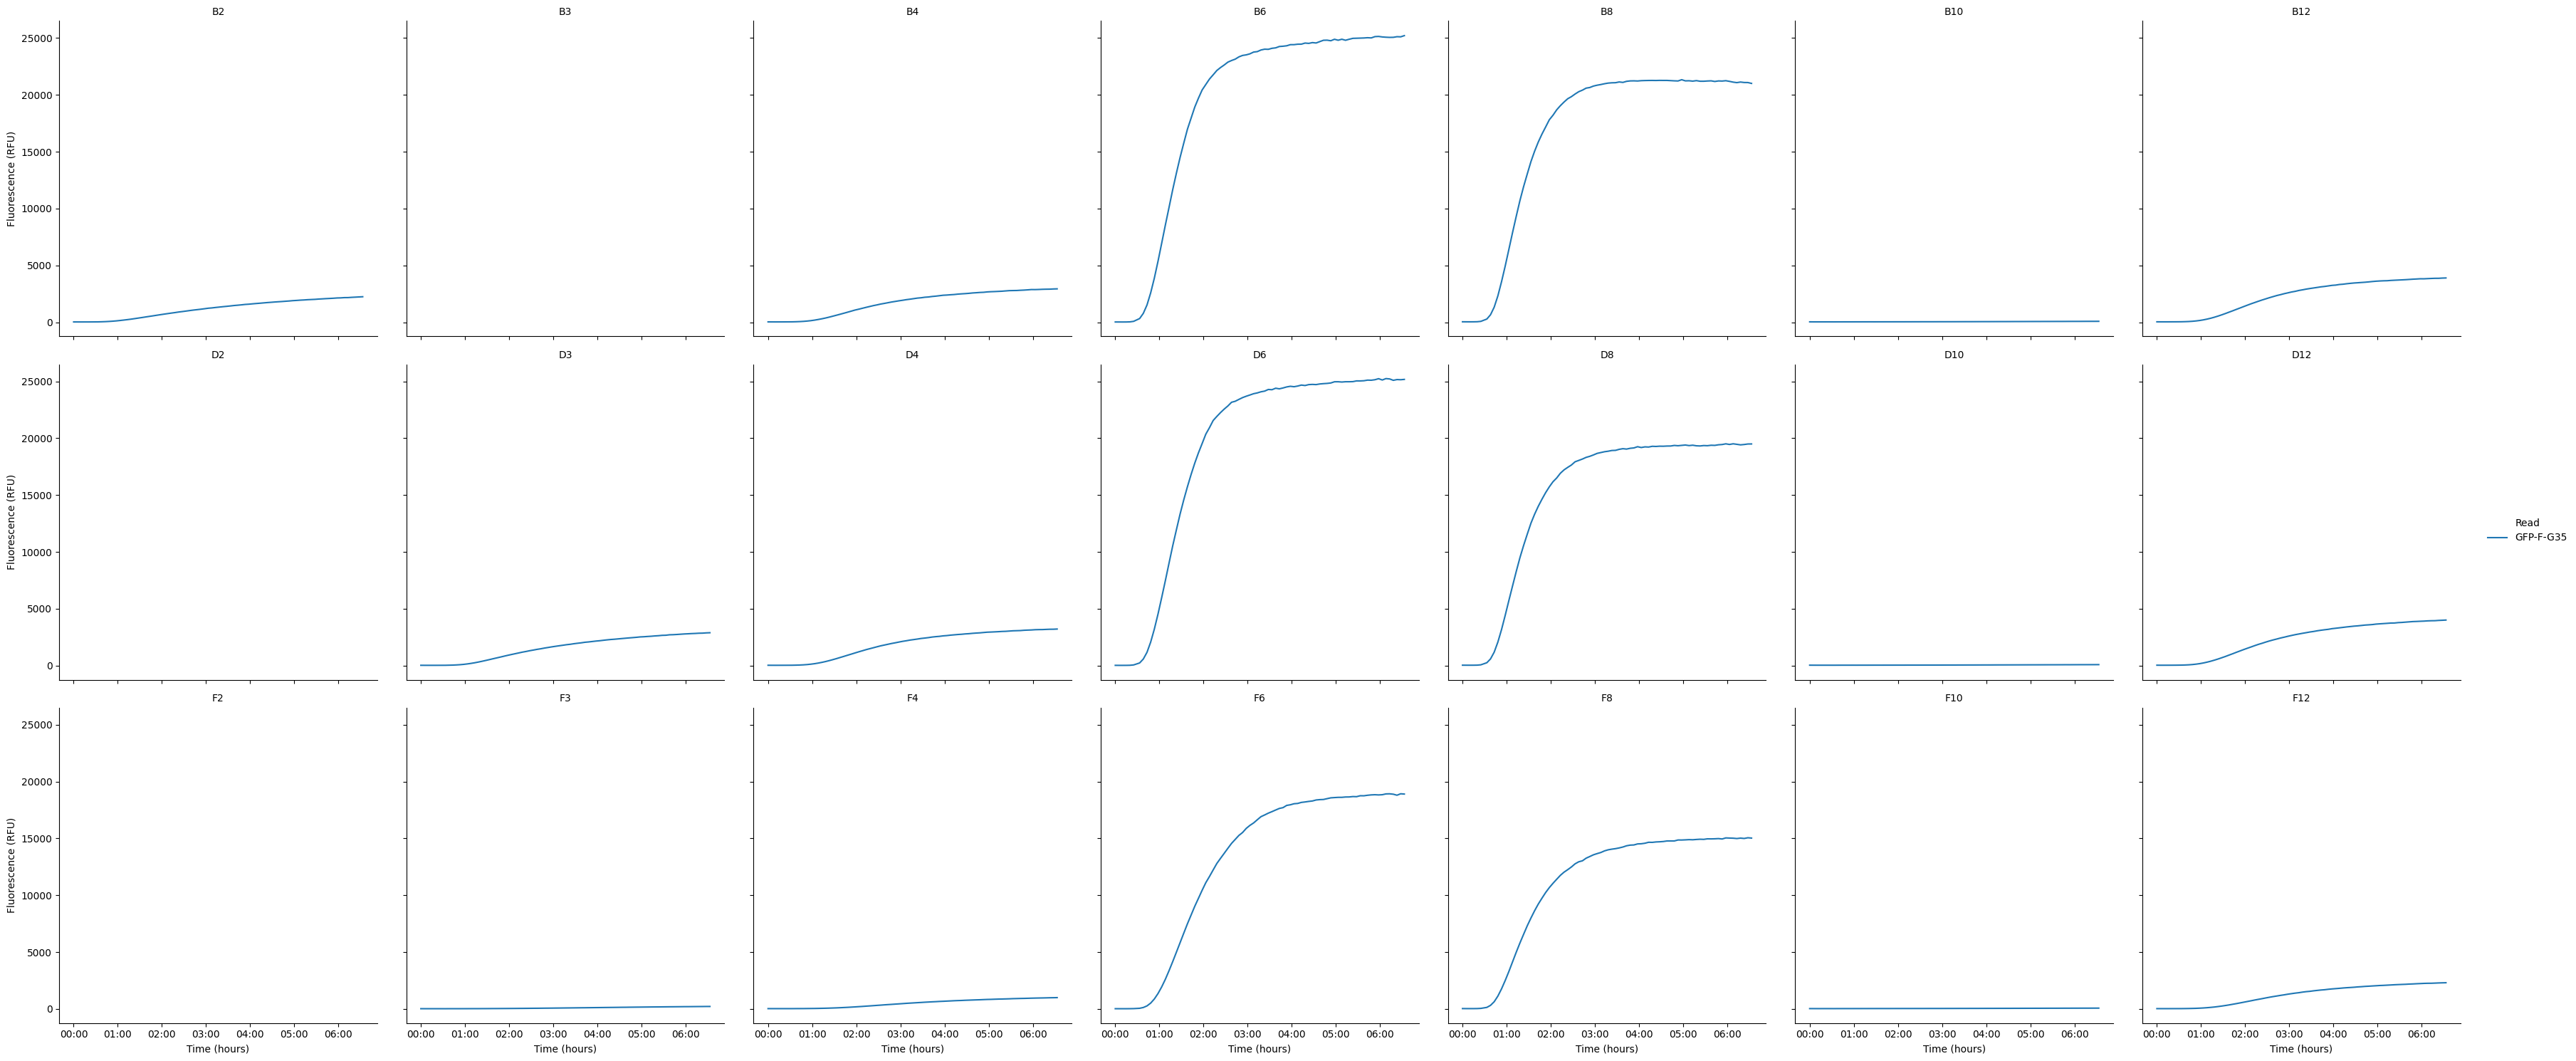

In [26]:
pr.plot_plate(data_merge)

In [14]:
data_merge.shape

(1422, 20)

[07/12/25 20:20:27] DEBUG    var_len=0                        platereader.py:627


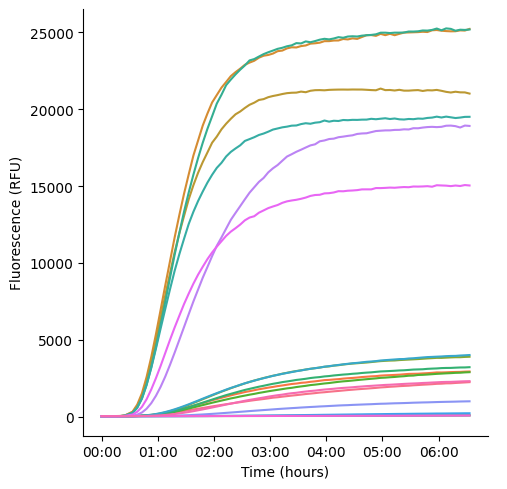

In [12]:
g = pr.plot_curves(data_merge, hue="Well", legend=False)
g.add_legend(ncol=4)
plt.show()
# sns.move_legend(g, "lower center", ncol=2)


In [13]:
data_merge.iloc[-1]

Time                    0 days 06:33:07
Well                                F12
Data                            2308.00
Row                                   F
Column                               12
Read                          GFP-F-G35
Plate                           Plate 2
Clock Time          2025-07-08 23:01:12
Type                             Sample
Name                            I + (2)
Replicate                             3
Emix                           NEB SolA
Pmix                                I -
[Pmix] (mg/mL)                      NaN
Energy Mix (uL)                       4
Protein Mix (uL)                   1.20
Ribosomes (uL)                     1.80
RNAse I (uL)                       0.50
DNA (uL)                           1.00
ddH2O (uL)                         1.50
Name: 1421, dtype: object

In [16]:
data = pr.read_biotek_cdk("../../tests/test_data/biotek_cdk_multiplate.txt")

[07/14/25 14:04:38] DEBUG    Reading CDK-formatted BioTek     platereader.py:232
                             data from                                          
                             ../../tests/test_data/biotek_cdk                   
                             _multiplate.txt                                    
                    DEBUG    Found metadata: CDK -> cdk       platereader.py:243
                    DEBUG    Found metadata: Procedure        platereader.py:243
                             Summary -> procedure_summary                       
                    DEBUG    Loaded section PURE:GFP-F-G35    platereader.py:268
                    DEBUG    Data loaded with columns:        platereader.py:314
                             Index(['Time', 'Well', 'Data'],                    
                             dtype='object')                                    
                    DEBUG    Found metadata: CDK -> cdk       platereader.py:243
                    DEBUG   

In [22]:
data_merge = pr.merge_plates(data)
data_merge.shape

[07/14/25 14:05:47] DEBUG    Start time: 2025-07-08 16:28:05 platereader.py:1233


(6083, 8)

[07/14/25 15:46:34] DEBUG    var_len=0                        platereader.py:641


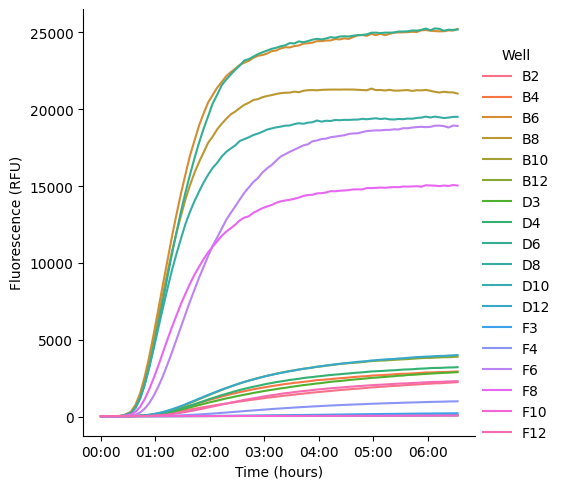

In [96]:
pr.plot_curves(data_merge, hue="Well")

<Axes: xlabel='Time', ylabel='Data'>

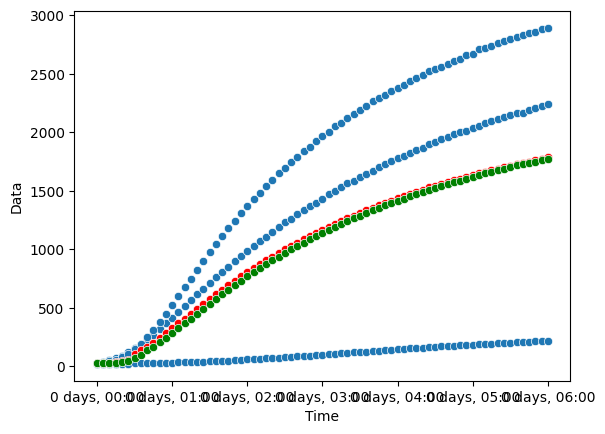

In [167]:
w = data[data["Name"] == data["Name"].iloc[0]]

# m = pd.DataFrame({
#     "Time": w["Time"],
#     "Data": w.rolling(3, min_periods=1)["Data"].mean()
# })
m = w.groupby("Time", as_index=False)["Data"].mean()
m["DataR"] = m["Data"].rolling(3, min_periods=1).mean()
# w["Time"].dt.total_seconds().diff()

ax = sns.scatterplot(w, x="Time", y="Data")
sns.scatterplot(m, x="Time", y="Data", c="red", ax=ax)
sns.scatterplot(m, x="Time", y="DataR", c="green", ax=ax)

In [168]:
pr.kinetic_analysis(data[data["Well"] == "B2"])

[07/14/25 16:32:59] DEBUG    Data mean:              Time     platereader.py:702
                             Data                                               
                             0 0 days 00:00:00 29.50                            
                             1 0 days 00:05:00 31.75                            
                             2 0 days 00:10:00 34.33                            
                             3 0 days 00:15:00 40.67                            
                             4 0 days 00:20:00 49.17                            
                    DEBUG    Scipy optimize warning:          platereader.py:726
                             Covariance of the parameters                       
                             could not be estimated                             
                    DEBUG    B2 Fitted params: [0, 0, 0]      platereader.py:731
                    DEBUG    V = (73,)                        platereader.py:735


/Users/acjs/b local/code/bnext/cdk/src/cdk/analysis/cytosol/platereader.py:793: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  )


Velocity                                   Lag       \
                Time   Data  Max                      Time Data   
Name                                                              
I -  0 days 00:40:00 191.67 0.17 0 days 00:21:34.230769231 0.00   

        Steady State         Fit        
                Time    Data   L  k x0  
Name                                    
I -  0 days 05:40:00 2159.67   0  0  0

In [183]:
kinetics = pr.kinetic_analysis(data)

[07/14/25 16:43:43] DEBUG    Data mean:              Time     platereader.py:699
                             Data                                               
                             0 0 days 00:00:00 26.00                            
                             1 0 days 00:05:00 25.33                            
                             2 0 days 00:10:00 25.00                            
                             3 0 days 00:15:00 24.56                            
                             4 0 days 00:20:00 24.56                            


                    DEBUG    B2 Fitted params:                platereader.py:735
                             [1.69198161e+03 3.17060998e-04                     
                             1.00338138e+04]                                    
                    DEBUG    V = (79,)                        platereader.py:739
                    DEBUG    Data mean:              Time     platereader.py:699
                             Data                                               
                             0 0 days 00:00:00 30.33                            
                             1 0 days 00:05:00 29.50                            
                             2 0 days 00:10:00 29.00                            
                             3 0 days 00:15:00 28.44                            
                             4 0 days 00:20:00 28.67                            
                    DEBUG    B4 Fitted params:                platereader.py:735
                            

/Users/acjs/b local/code/bnext/cdk/src/cdk/analysis/cytosol/platereader.py:797: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  def kinetic_analysis_summary(


In [3]:
data = pr.merge_plates(data)

[07/15/25 00:33:22] DEBUG    Start time: 2025-07-08 16:28:05 platereader.py:1258


[07/15/25 00:33:27] DEBUG    Logistic fit R^2:                platereader.py:735
                             0.580043456573934                                  
                    DEBUG    B4 Fitted params:                platereader.py:737
                             [2.23501997e+03 3.85469281e-04                     
                             9.08896666e+03]                                    
                    DEBUG    V = (79,)                        platereader.py:741
                    DEBUG    Plotting kinetics for group:     platereader.py:857
                             ['Name']                                           


                    DEBUG    Data index: ['I +']              platereader.py:866


/Users/acjs/b local/code/bnext/cdk/src/cdk/analysis/cytosol/platereader.py:800: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  kinetics = data.groupby(group_by, sort=False).apply(


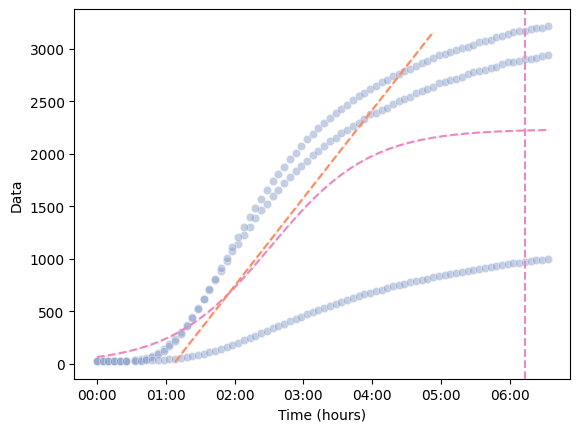

In [4]:
# dset = data[data["Name"] == "I +"]
dset = data[data["Name"] == "I +"]
kinetics = pr.kinetic_analysis(dset)
pr.plot_kinetics_by_well(dset, kinetics, group_by=["Name"], show_fit=True)

[07/15/25 00:37:13] DEBUG    Logistic fit R^2:                platereader.py:735
                             0.3962125530716625                                 
                    DEBUG    B2 Fitted params:                platereader.py:737
                             [1.69198161e+03 3.17060998e-04                     
                             1.00338138e+04]                                    
                    DEBUG    V = (79,)                        platereader.py:741
                    DEBUG    Logistic fit R^2:                platereader.py:735
                             0.580043456573934                                  
                    DEBUG    B4 Fitted params:                platereader.py:737
                             [2.23501997e+03 3.85469281e-04                     
                             9.08896666e+03]                                    
                    DEBUG    V = (79,)                        platereader.py:741
                    DEBUG   

/Users/acjs/b local/code/bnext/cdk/src/cdk/analysis/cytosol/platereader.py:800: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  kinetics = data.groupby(group_by, sort=False).apply(


[07/15/25 00:37:14] DEBUG    Plotting kinetics for group:     platereader.py:857
                             ['Name', 'Read']                                   
                    DEBUG    Data index: ['I +' 'GFP-F-G35']  platereader.py:866
                    DEBUG    Plotting data mean               platereader.py:873
                    DEBUG    Plotting kinetics for group:     platereader.py:857
                             ['Name', 'Read']                                   
                    DEBUG    Data index: ['NEB deltaRibo'     platereader.py:866
                             'GFP-F-G35']                                       
                    DEBUG    Plotting data mean               platereader.py:873
[07/15/25 00:37:15] DEBUG    Plotting kinetics for group:     platereader.py:857
                             ['Name', 'Read']                                   
                    DEBUG    Data index: ['Positive'          platereader.py:866
                            

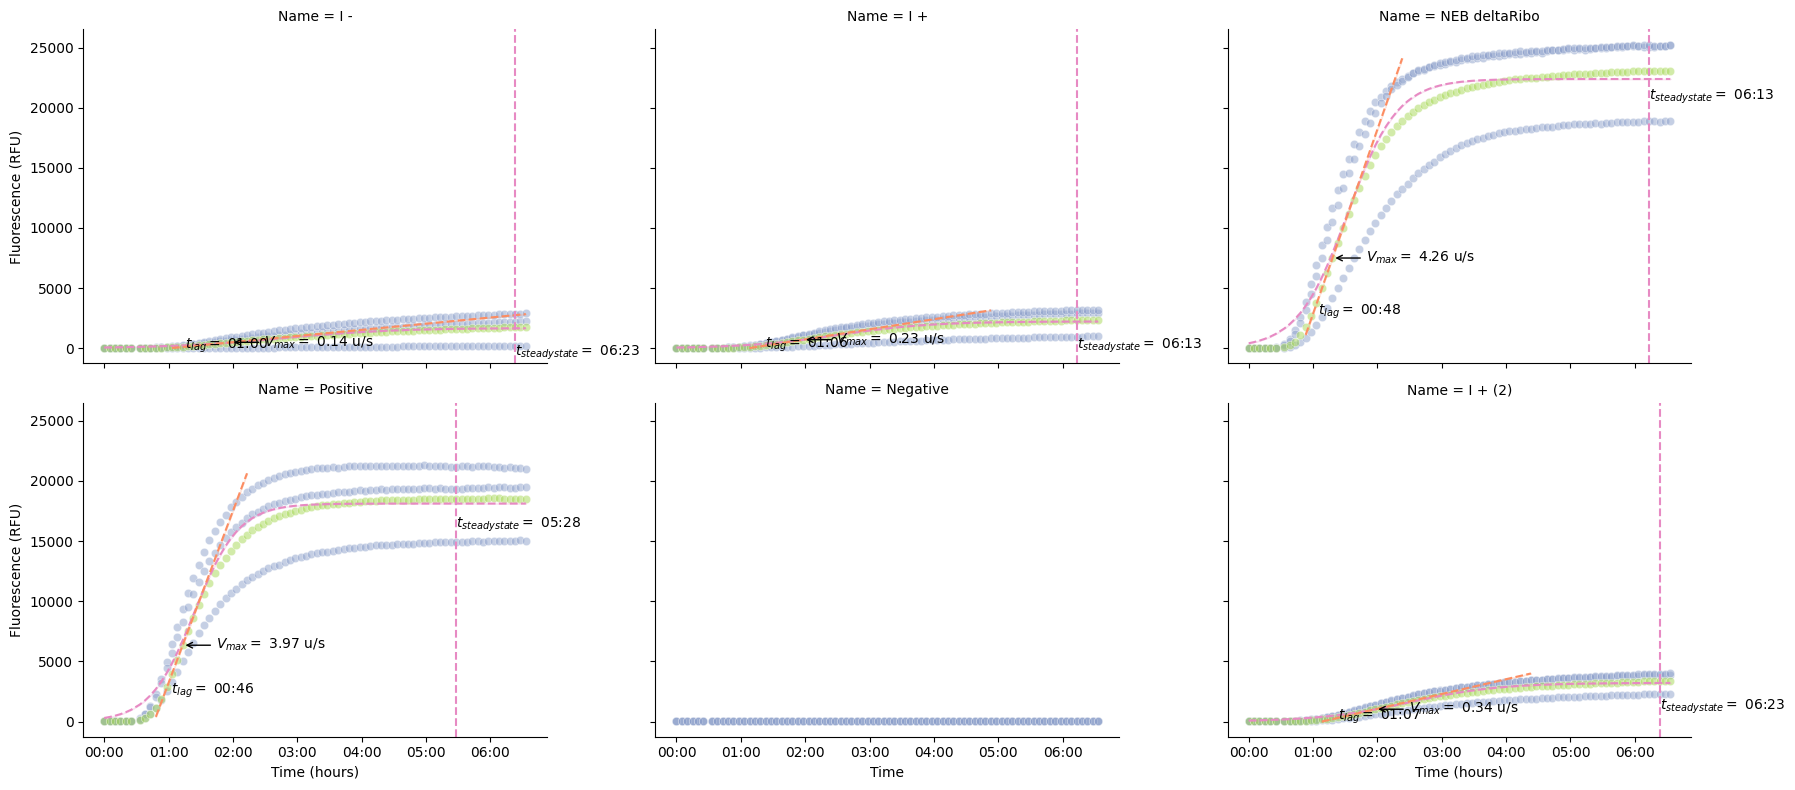

In [11]:
pr.plot_kinetics(data)

In [6]:
kinetics = pr.kinetic_analysis(data, group_by=["Name", "Read"])
kinetics

[07/15/25 00:33:50] DEBUG    Logistic fit R^2:                platereader.py:735
                             0.3962125530716625                                 
                    DEBUG    B2 Fitted params:                platereader.py:737
                             [1.69198161e+03 3.17060998e-04                     
                             1.00338138e+04]                                    
                    DEBUG    V = (79,)                        platereader.py:741
                    DEBUG    Logistic fit R^2:                platereader.py:735
                             0.580043456573934                                  
                    DEBUG    B4 Fitted params:                platereader.py:737
                             [2.23501997e+03 3.85469281e-04                     
                             9.08896666e+03]                                    
                    DEBUG    V = (79,)                        platereader.py:741


                    DEBUG    Logistic fit R^2:                platereader.py:735
                             0.8632481932104099                                 
                    DEBUG    B6 Fitted params:                platereader.py:737
                             [2.23846061e+04 7.16970352e-04                     
                             5.52636198e+03]                                    
                    DEBUG    V = (79,)                        platereader.py:741
                    DEBUG    Logistic fit R^2:                platereader.py:735
                             0.8704912176765023                                 
                    DEBUG    B8 Fitted params:                platereader.py:737
                             [1.81226889e+04 8.10780315e-04                     
                             5.03482024e+03]                                    
                    DEBUG    V = (79,)                        platereader.py:741
                    WARNING 

/Users/acjs/b local/code/bnext/cdk/src/cdk/analysis/cytosol/platereader.py:800: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  kinetics = data.groupby(group_by, sort=False).apply(


Velocity               \
                                   Time    Data  Max   
Name          Read                                     
I -           GFP-F-G35 0 days 01:58:07  494.44 0.14   
I +           GFP-F-G35 0 days 01:58:07  716.44 0.23   
NEB deltaRibo GFP-F-G35 0 days 01:18:07 7502.33 4.26   
Positive      GFP-F-G35 0 days 01:13:07 6347.56 3.97   
Negative      GFP-F-G35             NaT     NaN  NaN   
I + (2)       GFP-F-G35 0 days 01:58:07 1026.89 0.34   

                                              Lag            Steady State  \
                                             Time    Data            Time   
Name          Read                                                          
I -           GFP-F-G35    0 days 01:00:10.437500  195.28 0 days 06:23:07   
I +           GFP-F-G35 0 days 01:06:46.745222930  276.18 0 days 06:13:07   
NEB deltaRibo GFP-F-G35 0 days 00:48:44.509788567 3001.08 0 days 06:13:07   
Positive      GFP-F-G35 0 days 00:46:27.821125315 2522.96 0 days 05:28:07   
Negative      GFP-F-G35                       NaT     NaN             NaT   
I + (2)       GFP-F-G35 0 days 01:07:59.841648590  394.23 0 days 06:23:07   

                                      Fit                     
                            Data        L    k       x0  R^2  
Name          Read                                            
I -           GFP-F-G35  1749.00  1691.98 0.00 10033.81 0.40  
I +           GFP-F-G35  2337.78  2235.02 0.00  9088.97 0.58  
NEB deltaRibo GFP-F-G35 23060.22 22384.61 0.00  5526.36 0.86  
Positive      GFP-F-G35 18495.33 18122.69 0.00  5034.82 0.87  
Negative      GFP-F-G35      NaN      NaN  NaN      NaN  NaN  
I + (2)       GFP-F-G35  3364.89  3221.00 0.00  9014.37 0.81

In [200]:
kinetics

Velocity               \
                                   Time    Data  Max   
Name          Read                                     
I -           GFP-F-G35 0 days 01:58:07  494.44 0.14   
I +           GFP-F-G35 0 days 01:58:07  716.44 0.23   
NEB deltaRibo GFP-F-G35 0 days 01:18:07 7502.33 4.26   
Positive      GFP-F-G35 0 days 01:13:07 6347.56 3.97   
Negative      GFP-F-G35             NaT     NaN  NaN   
I + (2)       GFP-F-G35 0 days 01:58:07 1026.89 0.34   

                                              Lag            Steady State  \
                                             Time    Data            Time   
Name          Read                                                          
I -           GFP-F-G35    0 days 01:00:10.437500  195.28 0 days 06:23:07   
I +           GFP-F-G35 0 days 01:06:46.745222930  276.18 0 days 06:13:07   
NEB deltaRibo GFP-F-G35 0 days 00:48:44.509788567 3001.08 0 days 06:13:07   
Positive      GFP-F-G35 0 days 00:46:27.821125315 2522.96 0 days 05:28:07   
Negative      GFP-F-G35                       NaT     NaN             NaT   
I + (2)       GFP-F-G35 0 days 01:07:59.841648590  394.23 0 days 06:23:07   

                                      Fit                
                            Data        L    k       x0  
Name          Read                                       
I -           GFP-F-G35  1749.00  1691.98 0.00 10033.81  
I +           GFP-F-G35  2337.78  2235.02 0.00  9088.97  
NEB deltaRibo GFP-F-G35 23060.22 22384.61 0.00  5526.36  
Positive      GFP-F-G35 18495.33 18122.69 0.00  5034.82  
Negative      GFP-F-G35      NaN      NaN  NaN      NaN  
I + (2)       GFP-F-G35  3364.89  3221.00 0.00  9014.37

In [89]:
kinetics.index.names

FrozenList(['Name', 'Read'])

In [91]:
kinetics.loc[*data.loc[0, ["Name", "Read"]]]

Velocity      Time              0 days 01:05:00
              Data                       602.00
              Max                          0.26
Lag           Time    0 days 00:25:54.545454545
              Data                         0.00
Steady State  Time              0 days 06:00:00
              Data                       220.00
Fit           L                            0.00
              k                            0.00
              x0                           0.00
Name: (I -, GFP-F-G35), dtype: object

In [74]:
kinetics

Velocity               \
                                   Time    Data  Max   
Name          Read                                     
I -           GFP-F-G35 0 days 01:05:00  602.00 0.26   
I +           GFP-F-G35 0 days 01:15:00  912.00 0.33   
NEB deltaRibo GFP-F-G35 0 days 00:35:00 8556.00 5.34   
Positive      GFP-F-G35 0 days 00:35:00 7900.00 4.93   
Negative      GFP-F-G35 0 days 00:00:00   30.00 0.01   
I + (2)       GFP-F-G35 0 days 01:15:00 1133.00 0.42   

                                                Lag            Steady State  \
                                               Time    Data            Time   
Name          Read                                                            
I -           GFP-F-G35   0 days 00:25:54.545454545    0.00 0 days 06:00:00   
I +           GFP-F-G35             0 days 00:29:24  241.72 0 days 05:55:00   
NEB deltaRibo GFP-F-G35   0 days 00:08:18.752339364 1450.06 0 days 03:30:00   
Positive      GFP-F-G35   0 days 00:08:17.565922921 1354.32 0 days 04:10:00   
Negative      GFP-F-G35 -1 days +22:55:42.857142857   32.85 0 days 00:15:00   
I + (2)       GFP-F-G35   0 days 00:30:02.380952381  268.02 0 days 04:05:00   

                                      Fit               
                            Data        L    k      x0  
Name          Read                                      
I -           GFP-F-G35   220.00     0.00 0.00    0.00  
I +           GFP-F-G35  3201.00  2249.64 0.00 7189.06  
NEB deltaRibo GFP-F-G35 24423.00 21379.82 0.00 3415.92  
Positive      GFP-F-G35 19320.00 17859.03 0.00 3087.18  
Negative      GFP-F-G35    37.00    67.55 0.00 4403.22  
I + (2)       GFP-F-G35  3498.00  2887.90 0.00 6297.68

In [77]:
data.loc[0, ["Name"]]

Name    I -
Name: 0, dtype: object

In [81]:
kinetics.loc[*data.loc[0, ["Name"]]].shape

(1, 10)

In [44]:
kinetics.loc["I -", "GFP-F-G35"]

Velocity      Time              0 days 01:05:00
              Data                       602.00
              Max                          0.26
Lag           Time    0 days 00:25:54.545454545
              Data                         0.00
Steady State  Time              0 days 06:00:00
              Data                       220.00
Fit           L                            0.00
              k                            0.00
              x0                           0.00
Name: (I -, GFP-F-G35), dtype: object

In [36]:
kinetics = pr.kinetic_analysis(data)
kinetics

[07/15/25 12:27:42] DEBUG    Logistic fit R^2:                platereader.py:737
                             0.3962125530716625                                 
                    DEBUG    B2 Fitted params:                platereader.py:739
                             [1.69198161e+03 3.17060998e-04                     
                             1.00338138e+04]                                    
                    DEBUG    V = (79,)                        platereader.py:746
                    DEBUG    Logistic fit R^2:                platereader.py:737
                             0.580043456573934                                  
                    DEBUG    B4 Fitted params:                platereader.py:739
                             [2.23501997e+03 3.85469281e-04                     
                             9.08896666e+03]                                    


                    DEBUG    V = (79,)                        platereader.py:746
                    DEBUG    Logistic fit R^2:                platereader.py:737
                             0.8632481932104099                                 
                    DEBUG    B6 Fitted params:                platereader.py:739
                             [2.23846061e+04 7.16970352e-04                     
                             5.52636198e+03]                                    
                    DEBUG    V = (79,)                        platereader.py:746
                    DEBUG    Logistic fit R^2:                platereader.py:737
                             0.8704912176765023                                 
                    DEBUG    B8 Fitted params:                platereader.py:739
                             [1.81226889e+04 8.10780315e-04                     
                             5.03482024e+03]                                    
                    DEBUG   

/Users/acjs/b local/code/bnext/cdk/src/cdk/analysis/cytosol/platereader.py:807: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  kinetics = data.groupby(group_by, sort=False).apply(


Velocity                                    Lag          \
                         Time    Data  Max                      Time    Data   
Name                                                                           
I -           0 days 01:58:07  494.44 0.14    0 days 01:00:10.437500  195.28   
I +           0 days 01:58:07  716.44 0.23 0 days 01:06:46.745222930  276.18   
NEB deltaRibo 0 days 01:18:07 7502.33 4.26 0 days 00:48:44.509788567 3001.08   
Positive      0 days 01:13:07 6347.56 3.97 0 days 00:46:27.821125315 2522.96   
Negative                  NaT     NaN  NaN                       NaT     NaN   
I + (2)       0 days 01:58:07 1026.89 0.34 0 days 01:07:59.841648590  394.23   

                 Steady State               Fit                     
                         Time     Data        L    k       x0  R^2  
Name                                                                
I -           0 days 06:23:07  1749.00  1691.98 0.00 10033.81 0.40  
I +           0 days 06:13:07  2337.78  2235.02 0.00  9088.97 0.58  
NEB deltaRibo 0 days 06:13:07 23060.22 22384.61 0.00  5526.36 0.86  
Positive      0 days 05:28:07 18495.33 18122.69 0.00  5034.82 0.87  
Negative                  NaT      NaN      NaN  NaN      NaN  NaN  
I + (2)       0 days 06:23:07  3364.89  3221.00 0.00  9014.37 0.81

In [40]:
import timple
import timple.timedelta
f = timple.timedelta.TimedeltaFormatter("%h:%m:%s")

def format_timedelta(time, f="%h:%m"):
    try:
        return timple.timedelta.strftimedelta(x, f)
    except:
        return pd.NaT
   
# pd.IndexSlice[pd.IndexSlice[:, "Time"].notna(), pd.IndexSlice[:, "Time"]]
kinetics_styled = kinetics.style \
    .format(precision=2) \
    .format(lambda x: timple.timedelta.strftimedelta(x, "%h:%m"), subset=pd.IndexSlice[:, pd.IndexSlice[:, "Time"]])
kinetics_styled
        

ValueError: cannot convert float NaN to integer

In [41]:
pr.kinetic_analysis_summary(data)

[07/15/25 12:34:30] DEBUG    Logistic fit R^2:                platereader.py:737
                             0.3962125530716625                                 
                    DEBUG    B2 Fitted params:                platereader.py:739
                             [1.69198161e+03 3.17060998e-04                     
                             1.00338138e+04]                                    
                    DEBUG    V = (79,)                        platereader.py:746


                    DEBUG    Logistic fit R^2:                platereader.py:737
                             0.580043456573934                                  
                    DEBUG    B4 Fitted params:                platereader.py:739
                             [2.23501997e+03 3.85469281e-04                     
                             9.08896666e+03]                                    
                    DEBUG    V = (79,)                        platereader.py:746
                    DEBUG    Logistic fit R^2:                platereader.py:737
                             0.8632481932104099                                 
                    DEBUG    B6 Fitted params:                platereader.py:739
                             [2.23846061e+04 7.16970352e-04                     
                             5.52636198e+03]                                    
                    DEBUG    V = (79,)                        platereader.py:746
                    DEBUG   

/Users/acjs/b local/code/bnext/cdk/src/cdk/analysis/cytosol/platereader.py:807: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  kinetics = data.groupby(group_by, sort=False).apply(
